<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-48-bagging-intuition-theory-code?scriptVersionId=350354156" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0a1a2e 0%, #0f2847 50%, #0a1f3d 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #1e4080;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 48</span>
    <span style="background: rgba(255,255,255,0.08); color: #93c5fd; font-size: 11px; font-weight: 600; padding: 4px 12px; border-radius: 20px;">Theory + From-Scratch + sklearn</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">🛍️ Bagging</h1>
  <p style="color: #60a5fa; font-size: 16px; margin: 0 0 6px 0; font-style: italic;">Intuition, Theory &amp; Code — Bootstrap Aggregating</p>
  <p style="color: #bfdbfe; font-size: 15px; margin: 0 0 28px 0; max-width: 700px; line-height: 1.6;">Train hundreds of models on random subsets of data — then let them vote. The core idea behind Random Forest and one of the most reliable variance-reduction techniques in ML.</p>
  <div style="display: flex; gap: 20px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e4080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #3b82f6; font-size: 20px; font-weight: 700;">4 Variants</div>
      <div style="color: #93c5fd; font-size: 12px; margin-top: 2px;">Bagging · Pasting · Subspaces · Patches</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e4080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #3b82f6; font-size: 20px; font-weight: 700;">From Scratch</div>
      <div style="color: #93c5fd; font-size: 12px; margin-top: 2px;">Build manually before using sklearn</div>
    </div>
    <div style="background: rgba(255,255,255,0.06); border: 1px solid #1e4080; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #3b82f6; font-size: 20px; font-weight: 700;">OOB Score</div>
      <div style="color: #93c5fd; font-size: 12px; margin-top: 2px;">Free validation — no test set needed</div>
    </div>
  </div>
</div>

<div style="background: #060d1f; border-left: 5px solid #3b82f6; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #1e4080; border-left: 5px solid #3b82f6;">
  <h2 style="color: #3b82f6; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 4px;">
    <ol style="margin: 0; padding-left: 20px; color: #60a5fa; line-height: 2.1; font-size: 14px;">
      <li><a href='#concept' style='color: #60a5fa; text-decoration: none;'>What is Bagging &amp; Why It Works</a></li>
      <li><a href='#variants' style='color: #60a5fa; text-decoration: none;'>The 4 Variants Explained</a></li>
      <li><a href='#imports' style='color: #60a5fa; text-decoration: none;'>Imports</a></li>
      <li><a href='#data' style='color: #60a5fa; text-decoration: none;'>Dataset — Iris (Classification)</a></li>
      <li><a href='#scratch' style='color: #60a5fa; text-decoration: none;'>Bagging from Scratch — 3 Trees</a></li>
    </ol>
    <ol start="6" style="margin: 0; padding-left: 20px; color: #60a5fa; line-height: 2.1; font-size: 14px;">
      <li><a href='#sklearn-clf' style='color: #60a5fa; text-decoration: none;'>Bagging with sklearn — Classification</a></li>
      <li><a href='#oob' style='color: #60a5fa; text-decoration: none;'>OOB Score — Free Validation</a></li>
      <li><a href='#regression' style='color: #60a5fa; text-decoration: none;'>Bagging Regression — California Housing</a></li>
      <li><a href='#tuning' style='color: #60a5fa; text-decoration: none;'>Efficient Hyperparameter Search</a></li>
      <li><a href='#tips' style='color: #60a5fa; text-decoration: none;'>Bagging Tips &amp; Summary</a></li>
    </ol>
  </div>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎒 What is Bagging &amp; Why It Works</h2>
</div>

**Bagging (Bootstrap AGGregating)** was introduced by Leo Breiman in 1994. The core idea: train many instances of the **same algorithm** on different random subsets of the training data (bootstrap samples), then aggregate their predictions. It's the technique that powers **Random Forest**.

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 12px; padding: 24px 28px; margin: 20px 0;">
  <div style="color: #93c5fd; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 16px;">The Problem Bagging Solves</div>
  <div style="display: grid; grid-template-columns: 1fr auto 1fr; gap: 20px; align-items: center;">
    <div style="background: rgba(231,76,60,0.1); border: 1px solid #e74c3c; border-radius: 10px; padding: 16px;">
      <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 8px;">❌ Single Decision Tree</div>
      <div style="color: #bfdbfe; font-size: 13px; line-height: 1.6;">High variance — trained on slightly different data, produces a completely different tree. Memorises training noise. Unstable.</div>
    </div>
    <div style="text-align: center; color: #3b82f6; font-size: 24px;">→</div>
    <div style="background: rgba(59,130,246,0.1); border: 2px solid #3b82f6; border-radius: 10px; padding: 16px;">
      <div style="color: #3b82f6; font-weight: 700; font-size: 13px; margin-bottom: 8px;">✅ Bagging (500 Trees)</div>
      <div style="color: #bfdbfe; font-size: 13px; line-height: 1.6;">Low variance — individual trees still overfit, but their errors cancel out when averaged. Stable and robust.</div>
    </div>
  </div>
  <div style="margin-top: 16px; padding-top: 14px; border-top: 1px solid #1e4080; color: #bfdbfe; font-size: 13px; font-family: Georgia, serif; text-align: center;">
    If each of N independent trees has variance σ², their average has variance <strong style='color:#3b82f6;'>σ²/N</strong>. 500 trees → 0.2% of one tree's variance.
  </div>
</div>

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 10px; padding: 16px 22px; margin: 14px 0; font-size: 13px; color: #93c5fd;">
  <strong style="color: #3b82f6;">🔑 Bootstrap sampling explained:</strong> Draw N samples from N training points <strong style='color:#e0f0ff;'>with replacement</strong>. On average each bootstrap sample contains ~63.2% unique samples — the remaining ~36.8% are duplicates, and the excluded samples (never selected) are the <strong style='color:#3b82f6;'>Out-of-Bag (OOB)</strong> samples — a free validation set!
</div>

<a id='variants'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🗂️ The 4 Sampling Variants</h2>
</div>

The four variants differ only in **how they sample rows and features** for each base learner. Understanding the difference is key to choosing the right strategy.

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 10px; overflow: hidden; margin: 16px 0;">
  <table style="width: 100%; border-collapse: collapse; font-size: 13px;">
    <thead>
      <tr style="background: #0f2244;">
        <th style="padding: 12px 16px; color: #3b82f6; text-align: left;">Variant</th>
        <th style="padding: 12px 16px; color: #3b82f6; text-align: center;">Row Sampling</th>
        <th style="padding: 12px 16px; color: #3b82f6; text-align: center;">Feature Sampling</th>
        <th style="padding: 12px 16px; color: #3b82f6; text-align: left;">Best For</th>
        <th style="padding: 12px 16px; color: #3b82f6; text-align: left;">sklearn params</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #1e4080;">
        <td style="padding: 11px 16px; font-weight: 700; color: #3b82f6;">🎒 Bagging</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">With replacement</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">All features</td>
        <td style="padding: 11px 16px; color: #bfdbfe;">General purpose — default choice</td>
        <td style="padding: 11px 16px; color: #bfdbfe; font-family: monospace; font-size: 11px;">bootstrap=True</td>
      </tr>
      <tr style="border-bottom: 1px solid #1e4080; background: rgba(59,130,246,0.03);">
        <td style="padding: 11px 16px; font-weight: 700; color: #3b82f6;">📋 Pasting</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">Without replacement</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">All features</td>
        <td style="padding: 11px 16px; color: #bfdbfe;">When dataset is large enough, avoids duplicates</td>
        <td style="padding: 11px 16px; color: #bfdbfe; font-family: monospace; font-size: 11px;">bootstrap=False</td>
      </tr>
      <tr style="border-bottom: 1px solid #1e4080;">
        <td style="padding: 11px 16px; font-weight: 700; color: #3b82f6;">🌌 Random Subspaces</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">All rows</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">Random subset</td>
        <td style="padding: 11px 16px; color: #bfdbfe;">High-dimensional data (text, images)</td>
        <td style="padding: 11px 16px; color: #bfdbfe; font-family: monospace; font-size: 11px;">max_features&lt;1, bootstrap_features=True</td>
      </tr>
      <tr style="background: rgba(59,130,246,0.03);">
        <td style="padding: 11px 16px; font-weight: 700; color: #3b82f6;">🔲 Random Patches</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">Random subset</td>
        <td style="padding: 11px 16px; color: #bfdbfe; text-align: center;">Random subset</td>
        <td style="padding: 11px 16px; color: #bfdbfe;">Very high-dimensional, huge datasets</td>
        <td style="padding: 11px 16px; color: #bfdbfe; font-family: monospace; font-size: 11px;">max_samples&lt;1 + max_features&lt;1</td>
      </tr>
    </tbody>
  </table>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">📦 Imports</h2>
</div>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.datasets import make_classification, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, r2_score

try:
    from mlxtend.plotting import plot_decision_regions
    MLXTEND_OK = True
except ImportError:
    MLXTEND_OK = False

np.random.seed(42)
print("Imports complete.")

Imports complete.


<a id='data'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🌸 Dataset — Iris (Classification Scratch Demo)</h2>
</div>

We use the Iris dataset for the from-scratch bagging demo. We **keep only Versicolor (1) and Virginica (2)** — dropping Setosa — and use just `SepalWidthCm` and `PetalLengthCm` so we can visualise 2D decision boundaries clearly.

In [2]:
df = pd.read_csv(
    '/kaggle/input/datasets/uciml/iris/Iris.csv',
    usecols=lambda column: column not in ['Id']
)

# Encode species
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
print(f"Encoding: {dict(enumerate(encoder.classes_))}")

# Keep only Versicolor (1) and Virginica (2) — 2-class problem
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]
print(f"Shape after filtering: {df.shape}")
print(f"Class distribution: {df['Species'].value_counts().to_dict()}")

df.head()

Encoding: {0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'}
Shape after filtering: (100, 3)
Class distribution: {1: 50, 2: 50}


,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


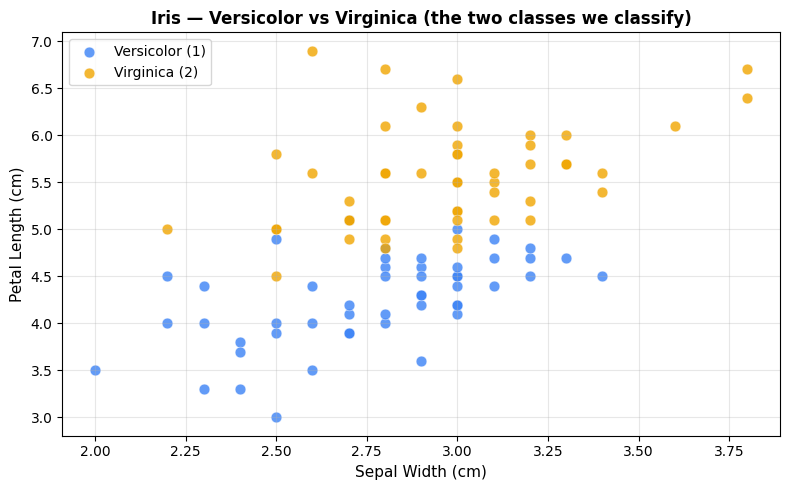

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {1: '#3b82f6', 2: '#f0a500'}
labels = {1: 'Versicolor (1)', 2: 'Virginica (2)'}
for cls in [1, 2]:
    subset = df[df['Species'] == cls]
    ax.scatter(subset['SepalWidthCm'], subset['PetalLengthCm'],
               c=colors[cls], label=labels[cls], s=60, alpha=0.8,
               edgecolors='white', linewidth=0.4)
ax.set_xlabel('Sepal Width (cm)', fontsize=11)
ax.set_ylabel('Petal Length (cm)', fontsize=11)
ax.set_title('Iris — Versicolor vs Virginica (the two classes we classify)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background: #060d1f; border-left: 4px solid #3b82f6; border-radius: 0 8px 8px 0; padding: 12px 18px; margin: 12px 0; font-size: 14px; color: #93c5fd;">
  <strong style="color: #e0f0ff;">💡 Why these two classes?</strong> Setosa is trivially separable — we remove it to create a harder, more realistic classification problem. Versicolor and Virginica overlap in feature space, which is exactly where ensemble methods shine over a single tree.
</div>

<a id='scratch'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🔨 Bagging from Scratch — 3 Trees</h2>
</div>

Before using sklearn's `BaggingClassifier`, we build it manually with 3 trees on 3 different bootstrap samples. This makes the mechanism transparent — each tree sees a **different random subset with replacement**, so they make different errors and their majority vote is more robust.

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 10px; padding: 14px 22px; margin: 14px 0; font-size: 13px; color: #93c5fd;">
  <strong style="color: #3b82f6;">Step-by-step process:</strong><br/>
  1. Take a small training set (10 rows)<br/>
  2. For each tree: sample 8 rows <strong style='color:#e0f0ff;'>with replacement</strong> (bootstrap sample) → some rows appear twice, others are skipped<br/>
  3. Train one Decision Tree on each bootstrap sample<br/>
  4. Predict by majority vote across all 3 trees
</div>

In [4]:
# Create small train / val / test splits for the scratch demo
df_sample = df.sample(100, random_state=42)
df_train  = df_sample.iloc[:60].sample(10, random_state=1)
df_val    = df_sample.iloc[60:80].sample(5, random_state=2)
df_test   = df_sample.iloc[80:].sample(5, random_state=3)

X_val = df_val.drop(columns=['Species'])
y_val = df_val['Species']

print(f"Training pool size : {df_train.shape[0]} rows")
print(f"Validation size    : {df_val.shape[0]} rows")
print(f"Test size          : {df_test.shape[0]} rows")
print(f"\nTraining pool:")
print(df_train)

Training pool size : 10 rows
Validation size    : 5 rows
Test size          : 5 rows

Training pool:
     SepalWidthCm  PetalLengthCm  Species
66            3.0            4.5        1
84            3.0            4.5        1
120           3.2            5.7        2
112           3.0            5.5        2
74            2.9            4.3        1
77            3.0            5.0        1
78            2.9            4.5        1
55            2.8            4.5        1
99            2.8            4.1        1
146           2.5            5.0        2


In [5]:
def evaluate_tree(clf, X_train_bag, y_train_bag, X_val, y_val, tree_name):
    """Train a tree on a bootstrap sample, plot its structure, and report accuracy."""
    clf.fit(X_train_bag, y_train_bag)
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Tree structure
    plot_tree(clf, feature_names=X_train_bag.columns.tolist(),
              class_names=['Versicolor', 'Virginica'],
              filled=True, rounded=True, ax=axes[0])
    axes[0].set_title(f'{tree_name} — Tree Structure', fontweight='bold')

    # Decision boundary
    x_min, x_max = X_val['SepalWidthCm'].min()-0.5, X_val['SepalWidthCm'].max()+0.5
    y_min, y_max = X_val['PetalLengthCm'].min()-0.5, X_val['PetalLengthCm'].max()+0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    from matplotlib.colors import ListedColormap
    axes[1].contourf(xx, yy, Z, alpha=0.25,
                     cmap=ListedColormap(['#1e3a5f', '#3a1a0f']))
    axes[1].scatter(X_train_bag['SepalWidthCm'], X_train_bag['PetalLengthCm'],
                    c=y_train_bag.map({1: '#3b82f6', 2: '#f0a500'}),
                    s=80, edgecolors='white', linewidth=0.5, label='Train (bootstrap)')
    axes[1].scatter(X_val['SepalWidthCm'], X_val['PetalLengthCm'],
                    c=y_val.map({1: '#3b82f6', 2: '#f0a500'}),
                    s=120, marker='*', edgecolors='white', linewidth=1, label='Validation')
    axes[1].set_xlabel('Sepal Width')
    axes[1].set_ylabel('Petal Length')
    axes[1].set_title(f'{tree_name} — Decision Boundary\nVal Accuracy: {acc:.2f}', fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)

    plt.suptitle(f'{tree_name}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    return clf, acc

print("Evaluation function defined.")

Evaluation function defined.


In [6]:
# Tree 1 — Bootstrap sample 1 (with replacement)
df_bag1 = df_train.sample(8, replace=True, random_state=10)
X_b1 = df_bag1.drop(columns=['Species'])
y_b1 = df_bag1['Species']

print("Bootstrap Sample 1 (note duplicate indices = same row sampled twice):")
print(df_bag1)
print(f"Unique rows: {df_bag1.index.nunique()} of 8 drawn  (rest are duplicates)")

Bootstrap Sample 1 (note duplicate indices = same row sampled twice):
     SepalWidthCm  PetalLengthCm  Species
146           2.5            5.0        2
74            2.9            4.3        1
66            3.0            4.5        1
84            3.0            4.5        1
146           2.5            5.0        2
66            3.0            4.5        1
84            3.0            4.5        1
99            2.8            4.1        1
Unique rows: 5 of 8 drawn  (rest are duplicates)


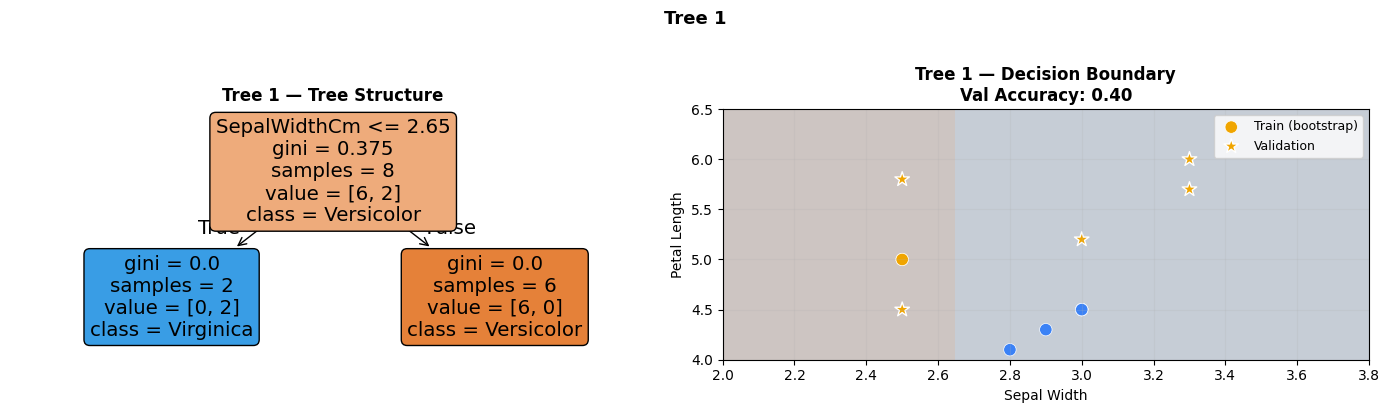

In [7]:
dt_bag1, acc1 = evaluate_tree(
    DecisionTreeClassifier(random_state=42),
    X_b1, y_b1, X_val, y_val, 'Tree 1')

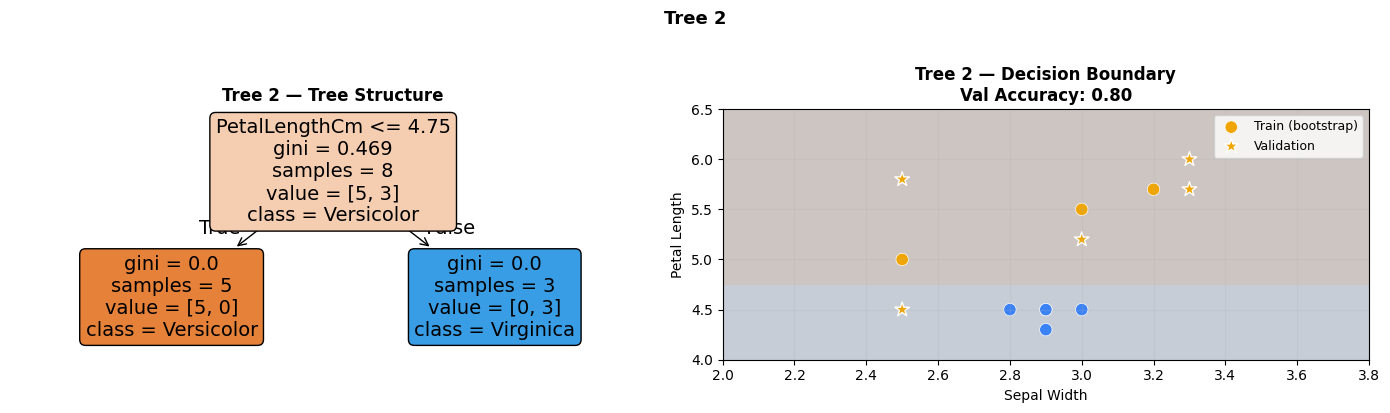

In [8]:
# Tree 2 — Different bootstrap sample
df_bag2 = df_train.sample(8, replace=True, random_state=20)
X_b2 = df_bag2.drop(columns=['Species'])
y_b2 = df_bag2['Species']

dt_bag2, acc2 = evaluate_tree(
    DecisionTreeClassifier(random_state=42),
    X_b2, y_b2, X_val, y_val, 'Tree 2')

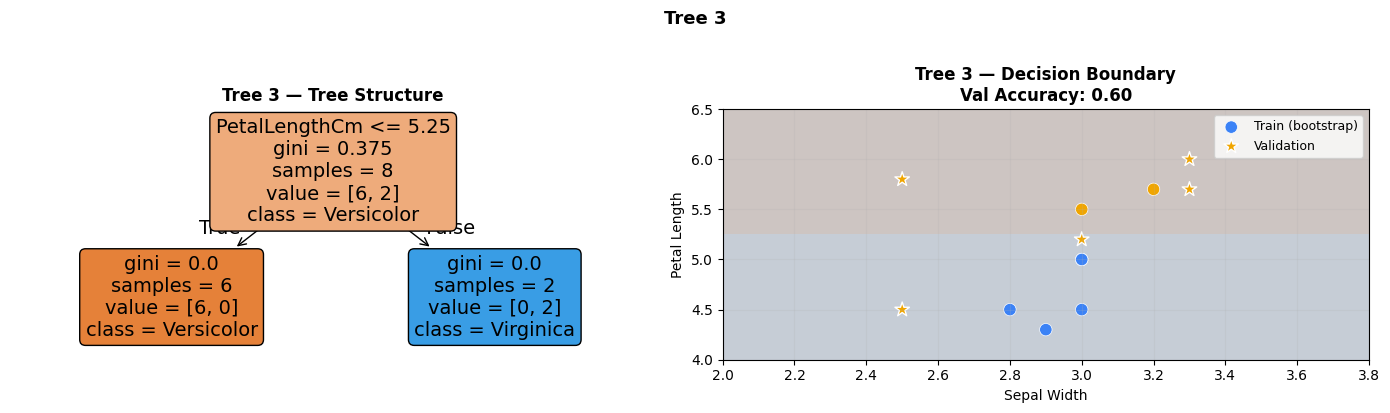

In [9]:
# Tree 3 — Yet another bootstrap sample
df_bag3 = df_train.sample(8, replace=True, random_state=30)
X_b3 = df_bag3.drop(columns=['Species'])
y_b3 = df_bag3['Species']

dt_bag3, acc3 = evaluate_tree(
    DecisionTreeClassifier(random_state=42),
    X_b3, y_b3, X_val, y_val, 'Tree 3')

In [10]:
# Majority vote on a new sample
query = np.array([[2.2, 5.0]])   # [SepalWidthCm, PetalLengthCm]

p1 = dt_bag1.predict(query)[0]
p2 = dt_bag2.predict(query)[0]
p3 = dt_bag3.predict(query)[0]

votes   = [p1, p2, p3]
final   = max(set(votes), key=votes.count)
species = {1: 'Versicolor', 2: 'Virginica'}

print(f"Query point: SepalWidth=2.2, PetalLength=5.0")
print(f"=" * 40)
print(f"  Tree 1 vote : {p1} ({species[p1]})")
print(f"  Tree 2 vote : {p2} ({species[p2]})")
print(f"  Tree 3 vote : {p3} ({species[p3]})")
print(f"=" * 40)
print(f"  Majority vote → {final} ({species[final]})")

Query point: SepalWidth=2.2, PetalLength=5.0
  Tree 1 vote : 2 (Virginica)
  Tree 2 vote : 2 (Virginica)
  Tree 3 vote : 1 (Versicolor)
  Majority vote → 2 (Virginica)


<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 10px; padding: 16px 22px; margin: 16px 0; font-size: 13px;">
  <div style="color: #3b82f6; font-weight: 700; margin-bottom: 10px;">📌 The 4 Sampling Cases Illustrated</div>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; font-size: 13px; color: #bfdbfe;">
    <div><strong style='color:#e0f0ff;'>Case 1 — Bagging:</strong> <code>df_train.sample(8, replace=True)</code><br/>Rows sampled with replacement → duplicates appear. The ~37% excluded rows become OOB.</div>
    <div><strong style='color:#e0f0ff;'>Case 2 — Pasting:</strong> <code>df_train.sample(8, replace=False)</code><br/>Rows sampled without replacement → no duplicates. Requires dataset larger than sample size.</div>
    <div><strong style='color:#e0f0ff;'>Case 3 — Random Subspaces:</strong> <code>df.sample(n, axis=1)</code><br/>Column (feature) sampling → each tree sees a random subset of features. Good for high-dim data.</div>
    <div><strong style='color:#e0f0ff;'>Case 4 — Random Patches:</strong> Row sampling + column sampling combined → maximum diversity between trees.</div>
  </div>
</div>

In [11]:
# Demonstrate the 4 sampling strategies with a quick visual
df1 = pd.read_csv('/kaggle/input/datasets/uciml/iris/Iris.csv',
                  usecols=lambda col: col != 'Id').sample(10, random_state=99)

print("=== Case 1: Bagging — row sampling WITH replacement ===")
print(df1.sample(8, replace=True, random_state=1).index.tolist(), "(duplicates possible)\n")

print("=== Case 2: Pasting — row sampling WITHOUT replacement ===")
print(df1.sample(8, replace=False, random_state=1).index.tolist(), "(no duplicates)\n")

print("=== Case 3: Random Subspaces — column sampling ===")
print(df1.sample(2, replace=True, axis=1, random_state=1).columns.tolist(), "(only 2 random features)\n")

print("=== Case 4: Random Patches — both row and column sampling ===")
patch = df1.sample(6, replace=True, random_state=1).sample(2, replace=True, axis=1, random_state=1)
print(f"Shape: {patch.shape} — {patch.columns.tolist()} features")

=== Case 1: Bagging — row sampling WITH replacement ===
[89, 24, 70, 89, 139, 139, 8, 108] (duplicates possible)

=== Case 2: Pasting — row sampling WITHOUT replacement ===
[74, 70, 78, 4, 139, 120, 8, 108] (no duplicates)

=== Case 3: Random Subspaces — column sampling ===
['PetalWidthCm', 'Species'] (only 2 random features)

=== Case 4: Random Patches — both row and column sampling ===
Shape: (6, 2) — ['PetalWidthCm', 'Species'] features


<a id='sklearn-clf'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🤖 Bagging with sklearn — Classification</h2>
</div>

Now we use sklearn's `BaggingClassifier` on a larger synthetic dataset (10,000 samples, 10 features). We compare a single Decision Tree vs all 4 bagging variants to quantify the accuracy improvement.

In [12]:
# Synthetic classification dataset — large enough to show bagging benefit clearly
X, y = make_classification(n_samples=10000, n_features=10, n_informative=3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# Baseline: single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_acc = accuracy_score(y_test, dt.predict(X_test))
print(f"\nBaseline — Single Decision Tree Accuracy : {dt_acc:.4f}")

Train: (7500, 10)  |  Test: (2500, 10)

Baseline — Single Decision Tree Accuracy : 0.9252


In [13]:
results = {'Single DT': dt_acc}

# 1. Bagging — row sampling with replacement
bag_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500, max_samples=0.5,
    bootstrap=True, random_state=42, n_jobs=-1
)
bag_bagging.fit(X_train, y_train)
results['Bagging'] = accuracy_score(y_test, bag_bagging.predict(X_test))
print(f"Bagging (500 DTs, 50% rows w/ replacement)  : {results['Bagging']:.4f}")

# 2. Pasting — row sampling without replacement
bag_pasting = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, max_samples=0.25,
    bootstrap=False, random_state=42, n_jobs=-1
)
bag_pasting.fit(X_train, y_train)
results['Pasting'] = accuracy_score(y_test, bag_pasting.predict(X_test))
print(f"Pasting (100 DTs, 25% rows w/o replacement) : {results['Pasting']:.4f}")

# 3. Random Subspaces — feature sampling only
bag_subspaces = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500, max_samples=1.0,
    bootstrap=False, max_features=0.5,
    bootstrap_features=True, random_state=42, n_jobs=-1
)
bag_subspaces.fit(X_train, y_train)
results['Random Subspaces'] = accuracy_score(y_test, bag_subspaces.predict(X_test))
print(f"Random Subspaces (500 DTs, 50% features)    : {results['Random Subspaces']:.4f}")

# 4. Random Patches — both row and feature sampling
bag_patches = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500, max_samples=0.25,
    bootstrap=True, max_features=0.5,
    bootstrap_features=True, random_state=42, n_jobs=-1
)
bag_patches.fit(X_train, y_train)
results['Random Patches'] = accuracy_score(y_test, bag_patches.predict(X_test))
print(f"Random Patches (500 DTs, 25% rows + 50% feat): {results['Random Patches']:.4f}")

# Bagging with SVM base learner (different base estimator)
bag_svm = BaggingClassifier(
    estimator=SVC(probability=False),
    n_estimators=50, max_samples=0.5,
    bootstrap=True, random_state=42, n_jobs=-1
)
bag_svm.fit(X_train, y_train)
results['Bagging (SVM)'] = accuracy_score(y_test, bag_svm.predict(X_test))
print(f"Bagging SVM (50 SVMs, 50% rows)              : {results['Bagging (SVM)']:.4f}")

Bagging (500 DTs, 50% rows w/ replacement)  : 0.9500
Pasting (100 DTs, 25% rows w/o replacement) : 0.9464
Random Subspaces (500 DTs, 50% features)    : 0.9404
Random Patches (500 DTs, 25% rows + 50% feat): 0.9392
Bagging SVM (50 SVMs, 50% rows)              : 0.9148


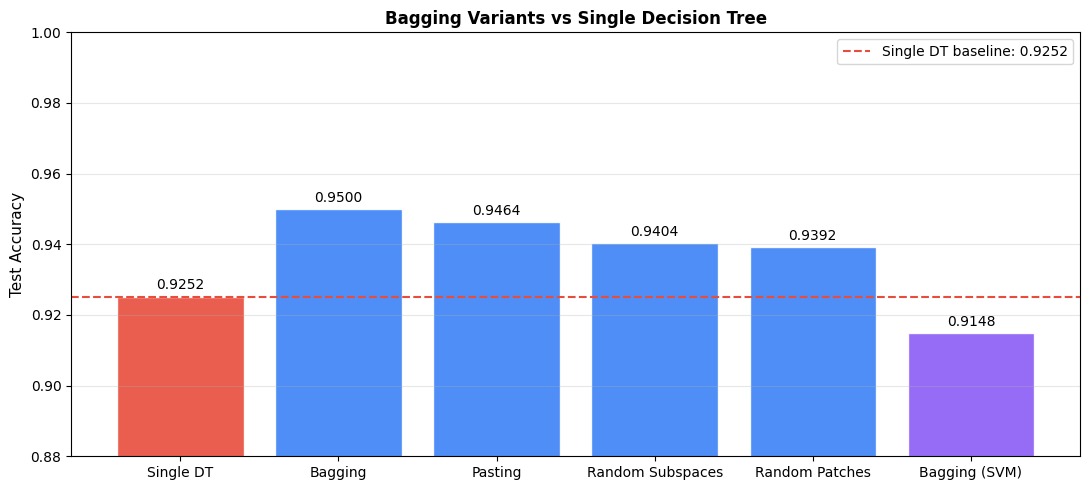

In [14]:
# Visual comparison
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c'] + ['#3b82f6'] * 4 + ['#8b5cf6']
bars = ax.bar(results.keys(), results.values(),
              color=colors, alpha=0.9, edgecolor='white')
ax.bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
ax.axhline(dt_acc, color='#e74c3c', linewidth=1.5, linestyle='--',
           label=f'Single DT baseline: {dt_acc:.4f}')
ax.set_ylim(0.88, 1.0)
ax.set_ylabel('Test Accuracy', fontsize=11)
ax.set_title('Bagging Variants vs Single Decision Tree', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<a id='oob'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🎁 OOB Score — Free Validation</h2>
</div>

**Out-of-Bag (OOB) scoring** is one of Bagging's most useful features. Since each tree is trained on ~63% of training data, the remaining ~37% (excluded samples) can be used to evaluate that tree for free — without touching the test set. Each training sample is evaluated only by the trees that did NOT see it.

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 8px; padding: 14px 20px; margin: 14px 0; font-size: 13px; color: #93c5fd;">
  <strong style="color: #3b82f6;">Why this is powerful:</strong> OOB score gives you a reliable generalisation estimate <strong style='color:#e0f0ff;'>without any cross-validation or test split</strong>. It's essentially a free 5-fold cross-validation built into the training process itself. The OOB score closely tracks true test accuracy.
</div>

In [15]:
# Enable OOB scoring
bag_oob = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=500, max_samples=0.25,
    bootstrap=True,
    oob_score=True,          # ← enable OOB evaluation
    random_state=42, n_jobs=-1
)
bag_oob.fit(X_train, y_train)

oob_score  = bag_oob.oob_score_
test_score = accuracy_score(y_test, bag_oob.predict(X_test))

print(f"OOB Score  (no test set used)  : {oob_score:.4f}")
print(f"Test Score (actual test set)   : {test_score:.4f}")
print(f"Difference                     : {abs(oob_score - test_score):.4f}")
print(f"\nSamples used per tree: {bag_oob.estimators_samples_[0].shape[0]}")
print(f"Features used per tree: {bag_oob.estimators_features_[0].shape[0]}")

OOB Score  (no test set used)  : 0.9417
Test Score (actual test set)   : 0.9456
Difference                     : 0.0039

Samples used per tree: 1875
Features used per tree: 10


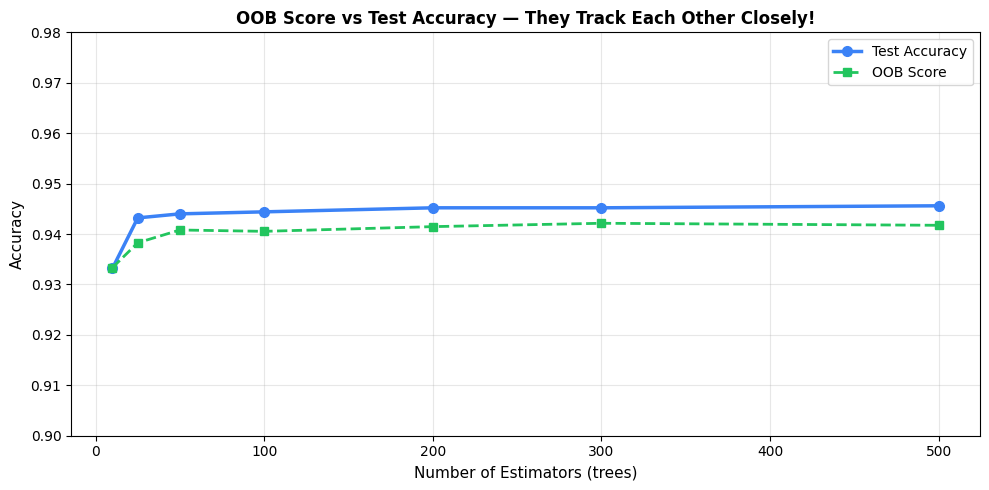

In [16]:
# Show OOB score tracks test accuracy as n_estimators increases
n_vals = [10, 25, 50, 100, 200, 300, 500]
oob_scores, test_scores = [], []

for n in n_vals:
    b = BaggingClassifier(
        estimator=DecisionTreeClassifier(),
        n_estimators=n, max_samples=0.25,
        bootstrap=True, oob_score=True,
        random_state=42, n_jobs=-1
    )
    b.fit(X_train, y_train)
    oob_scores.append(b.oob_score_)
    test_scores.append(accuracy_score(y_test, b.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_vals, test_scores, 'o-', color='#3b82f6', linewidth=2.5, markersize=7, label='Test Accuracy')
ax.plot(n_vals, oob_scores,  's--', color='#22c55e', linewidth=2,   markersize=6, label='OOB Score')
ax.set_xlabel('Number of Estimators (trees)', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('OOB Score vs Test Accuracy — They Track Each Other Closely!', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.90, 0.98)
plt.tight_layout()
plt.show()

<a id='regression'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 8</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">🏠 Bagging Regression — California Housing</h2>
</div>

Bagging works for regression too — instead of majority vote, it **averages predictions** across all base regressors. We test on the California Housing dataset (20,640 samples, 8 features) and compare individual regressors vs `BaggingRegressor`.

In [17]:
houses = fetch_california_housing()
X_h, y_h = houses.data, houses.target

print(f"Features : {houses.feature_names}")
print(f"Shape    : {X_h.shape}")
print(f"Target   : Median house value (×$100k), range [{y_h.min():.2f}, {y_h.max():.2f}]")

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_h, y_h, train_size=0.80, test_size=0.20, random_state=123
)
print(f"\nTrain: {X_train_h.shape}  |  Test: {X_test_h.shape}")

Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape    : (20640, 8)
Target   : Median house value (×$100k), range [0.15, 5.00]

Train: (16512, 8)  |  Test: (4128, 8)


In [18]:
# Individual baseline regressors
reg_baselines = {
    'Linear Regression': LinearRegression(),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'KNN':               KNeighborsRegressor(n_neighbors=5),
}

print(f"{'Model':<22} {'Train R²':>10} {'Test R²':>10}")
print("-" * 44)
reg_results = {}
for name, model in reg_baselines.items():
    model.fit(X_train_h, y_train_h)
    train_r2 = r2_score(y_train_h, model.predict(X_train_h))
    test_r2  = r2_score(y_test_h,  model.predict(X_test_h))
    reg_results[name] = test_r2
    print(f"{name:<22} {train_r2:>10.4f} {test_r2:>10.4f}")

Model                    Train R²    Test R²
--------------------------------------------
Linear Regression          0.6051     0.6105
Decision Tree              1.0000     0.6148
KNN                        0.4529     0.1626


In [19]:
# BaggingRegressor — default (DT base)
bag_reg = BaggingRegressor(random_state=42, n_jobs=-1)
bag_reg.fit(X_train_h, y_train_h)

train_r2_bag = r2_score(y_train_h, bag_reg.predict(X_train_h))
test_r2_bag  = r2_score(y_test_h,  bag_reg.predict(X_test_h))

reg_results['BaggingRegressor'] = test_r2_bag
print(f"BaggingRegressor (default)")
print(f"  Train R² : {train_r2_bag:.4f}")
print(f"  Test  R² : {test_r2_bag:.4f}")

BaggingRegressor (default)
  Train R² : 0.9618
  Test  R² : 0.7923


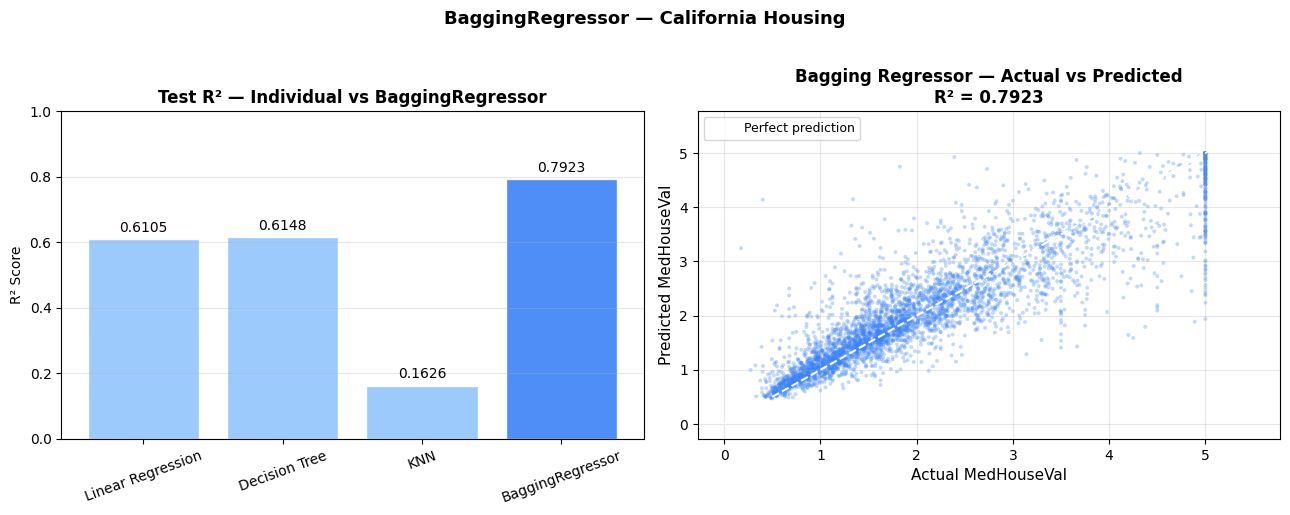

In [20]:
# Visualise regression performance + prediction scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
bar_colors = ['#93c5fd'] * 3 + ['#3b82f6']
bars = axes[0].bar(reg_results.keys(), reg_results.values(),
                   color=bar_colors, alpha=0.9, edgecolor='white')
axes[0].bar_label(bars, fmt='%.4f', fontsize=10, padding=3)
axes[0].set_ylim(0, 1)
axes[0].set_title('Test R² — Individual vs BaggingRegressor', fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)

# Predicted vs actual
y_pred_bag = bag_reg.predict(X_test_h)
axes[1].scatter(y_test_h, y_pred_bag, alpha=0.3, s=8,
                color='#3b82f6', edgecolors='none')
lims = [0, 5.5]
axes[1].plot(lims, lims, 'w--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual MedHouseVal', fontsize=11)
axes[1].set_ylabel('Predicted MedHouseVal', fontsize=11)
axes[1].set_title(f'Bagging Regressor — Actual vs Predicted\nR² = {test_r2_bag:.4f}', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('BaggingRegressor — California Housing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<a id='tuning'></a>
<div style="border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #3b82f6; color: #fff; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 9</span>
  <h2 style="color: #e0f0ff; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">⚡ Efficient Hyperparameter Search</h2>
</div>

<div style="background: #060d1f; border: 1px solid #1e4080; border-radius: 10px; padding: 18px 22px; margin: 16px 0; font-size: 13px;">
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px;">
    <div>
      <div style="color: #3b82f6; font-weight: 700; margin-bottom: 6px;">🎲 RandomizedSearchCV</div>
      <div style="color: #bfdbfe; line-height: 1.6;">Sample only <code>n_iter=20</code> random combinations instead of all 144. Statistically just as good at finding good regions of hyperparameter space.</div>
    </div>
    <div>
      <div style="color: #3b82f6; font-weight: 700; margin-bottom: 6px;">✂️ Subsample Data</div>
      <div style="color: #bfdbfe; line-height: 1.6;">Use only 30% of training data for the search. The best hyperparameters on 5K rows are usually the same as on 16K rows — much faster to fit.</div>
    </div>
    <div>
      <div style="color: #3b82f6; font-weight: 700; margin-bottom: 6px;">⚙️ Fewer Estimators</div>
      <div style="color: #bfdbfe; line-height: 1.6;">During search, use only 20 trees — not 100+. We care about which hyperparameters work, not the final performance. Final model uses more trees.</div>
    </div>
  </div>
</div>

In [21]:
import time

# Strategy: subsample to 30% for faster search
idx_sample = np.random.choice(len(X_train_h), size=int(0.30 * len(X_train_h)), replace=False)
X_search = X_train_h[idx_sample]
y_search = y_train_h[idx_sample]

print(f"Full train size   : {X_train_h.shape[0]:,}")
print(f"Search subset size: {X_search.shape[0]:,}  (30% subsample — much faster)")

# Broad but manageable parameter distributions
param_dist = {
    'n_estimators':      [10, 20, 50],          # fewer for search (speed)
    'max_samples':       [0.3, 0.5, 0.7, 1.0],
    'max_features':      [0.5, 0.7, 1.0],
    'bootstrap':         [True, False],
    'bootstrap_features': [True, False],
}

# RandomizedSearchCV: only 20 random combos × 3 folds = 60 fits (vs 432!)
random_search = RandomizedSearchCV(
    estimator=BaggingRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,             # ← key: only 20 random combinations
    cv=3,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

start = time.time()
random_search.fit(X_search, y_search)
elapsed = time.time() - start

print(f"\nSearch completed in {elapsed:.1f}s")
print(f"Best CV R² (on 30% subset) : {random_search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<22}: {v}")

Full train size   : 16,512
Search subset size: 4,953  (30% subsample — much faster)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Search completed in 12.2s
Best CV R² (on 30% subset) : 0.7587
Best parameters:
  n_estimators          : 50
  max_samples           : 0.5
  max_features          : 0.7
  bootstrap_features    : False
  bootstrap             : False


In [22]:
# Retrain the best configuration on the FULL training data, with more trees
best_params = random_search.best_params_.copy()
best_params['n_estimators'] = 100    # scale up trees for final model

final_model = BaggingRegressor(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X_train_h, y_train_h)

train_r2_final = r2_score(y_train_h, final_model.predict(X_train_h))
test_r2_final  = r2_score(y_test_h,  final_model.predict(X_test_h))

print("Final model trained on 100% of training data with best hyperparameters:")
print(f"  Train R² : {train_r2_final:.4f}")
print(f"  Test  R² : {test_r2_final:.4f}")
print(f"\nComparison:")
print(f"  Default BaggingRegressor : {test_r2_bag:.4f}")
print(f"  Tuned  BaggingRegressor  : {test_r2_final:.4f}  (improvement: {test_r2_final - test_r2_bag:+.4f})")

Final model trained on 100% of training data with best hyperparameters:
  Train R² : 0.9502
  Test  R² : 0.8174

Comparison:
  Default BaggingRegressor : 0.7923
  Tuned  BaggingRegressor  : 0.8174  (improvement: +0.0251)


In [23]:
# Show CV results — which combinations performed best
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')[[
    'param_n_estimators', 'param_max_samples', 'param_max_features',
    'param_bootstrap', 'mean_test_score', 'std_test_score'
]].head(10).reset_index(drop=True)
cv_results.columns = ['n_est', 'max_samp', 'max_feat', 'bootstrap', 'CV R² Mean', 'CV R² Std']
cv_results['CV R² Mean'] = cv_results['CV R² Mean'].round(4)
cv_results['CV R² Std']  = cv_results['CV R² Std'].round(4)
print("Top 10 parameter combinations from RandomizedSearchCV:")
print(cv_results.to_string(index=False))

Top 10 parameter combinations from RandomizedSearchCV:
 n_est  max_samp  max_feat  bootstrap  CV R² Mean  CV R² Std
    50       0.5       0.7      False      0.7587     0.0050
    50       0.7       0.7       True      0.7569     0.0030
    50       0.5       1.0       True      0.7408     0.0010
    20       0.5       1.0       True      0.7312     0.0043
    20       0.5       1.0      False      0.7299     0.0013
    20       0.3       1.0      False      0.7289     0.0026
    10       0.5       0.7       True      0.7250     0.0080
    10       1.0       1.0       True      0.7213     0.0025
    10       0.7       1.0       True      0.7182     0.0063
    20       0.3       1.0      False      0.7166     0.0061


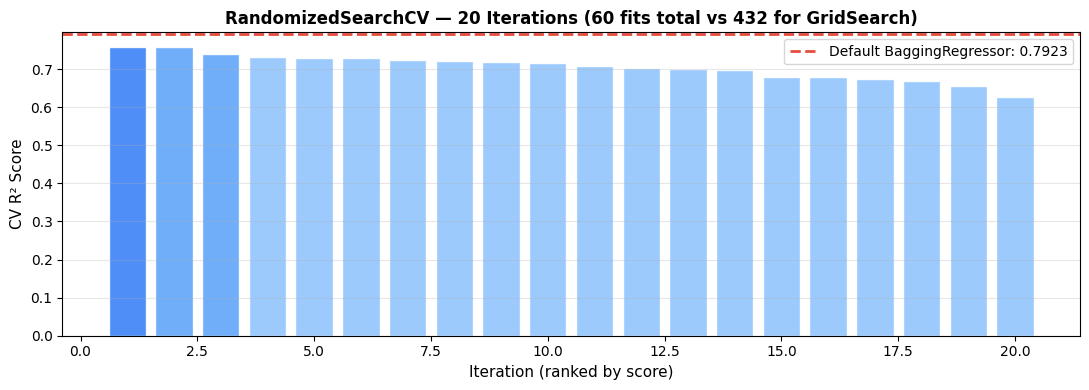

In [24]:
# Visualise all 20 CV mean scores
all_scores = pd.DataFrame(random_search.cv_results_).sort_values(
    'mean_test_score', ascending=False
)['mean_test_score'].values

fig, ax = plt.subplots(figsize=(11, 4))
colors_bar = ['#3b82f6' if i == 0 else '#60a5fa' if i < 3 else '#93c5fd' for i in range(len(all_scores))]
bars = ax.bar(range(1, len(all_scores)+1), all_scores, color=colors_bar, alpha=0.9, edgecolor='white')
ax.axhline(test_r2_bag, color='#e74c3c', linewidth=2, linestyle='--',
           label=f'Default BaggingRegressor: {test_r2_bag:.4f}')
ax.set_xlabel('Iteration (ranked by score)', fontsize=11)
ax.set_ylabel('CV R² Score', fontsize=11)
ax.set_title('RandomizedSearchCV — 20 Iterations (60 fits total vs 432 for GridSearch)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<a id='tips'></a>
<div style="background: linear-gradient(135deg, #0a1a2e 0%, #0f2847 100%); border: 1px solid #1e4080; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Bagging Tips &amp; Key Takeaways</h2>
  <p style="color: #93c5fd; font-size: 13px; margin: 0 0 20px 0;">Practical rules for applying Bagging effectively.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(59,130,246,0.08); border: 1px solid #1e4080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #3b82f6; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🎯 Sampling Sweet Spot</div>
      <div style="color: #bfdbfe; font-size: 12px; line-height: 1.7;">Best results typically at <strong style='color:#e0f0ff;'>25–50% row sampling</strong>. Too little → trees are too different and underfit. Too much → trees are too similar and variance doesn't reduce.</div>
    </div>
    <div style="background: rgba(59,130,246,0.08); border: 1px solid #1e4080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #3b82f6; font-weight: 700; font-size: 13px; margin-bottom: 6px;">📐 Feature Tricks</div>
      <div style="color: #bfdbfe; font-size: 12px; line-height: 1.7;">Random Subspaces and Patches excel with <strong style='color:#e0f0ff;'>high-dimensional data</strong> (text, genomics, images). When features &gt; 100, reducing feature subset size often improves accuracy significantly.</div>
    </div>
    <div style="background: rgba(59,130,246,0.08); border: 1px solid #1e4080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #3b82f6; font-weight: 700; font-size: 13px; margin-bottom: 6px;">⚡ Tuning Efficiently</div>
      <div style="color: #bfdbfe; font-size: 12px; line-height: 1.7;">Use <strong style='color:#e0f0ff;'>RandomizedSearchCV</strong> on a 20–30% data subsample. Best hyperparameters generalise well. Then retrain the final model with more trees on full data.</div>
    </div>
    <div style="background: rgba(59,130,246,0.08); border: 1px solid #1e4080; border-radius: 10px; padding: 16px 18px;">
      <div style="color: #3b82f6; font-weight: 700; font-size: 13px; margin-bottom: 6px;">🎁 Free OOB Validation</div>
      <div style="color: #bfdbfe; font-size: 12px; line-height: 1.7;">Always set <code>oob_score=True</code> with bootstrap=True. OOB score ≈ test score and tracks generalisation during training — essentially free cross-validation.</div>
    </div>
  </div>
  <div style="background: rgba(59,130,246,0.1); border: 1px solid #1e4080; border-radius: 10px; padding: 16px 22px; margin-bottom: 16px; font-size: 13px;">
    <div style="color: #3b82f6; font-weight: 700; margin-bottom: 8px;">⚡ GridSearch vs RandomizedSearch — Speed Comparison</div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 12px; color: #bfdbfe;">
      <div><strong style='color:#e74c3c;'>GridSearchCV (original):</strong><br/>144 combos × 3 folds = <strong style='color:#e74c3c;'>432 fits</strong> on 16,512 rows → &gt;30 min → <strong>timed out</strong></div>
      <div><strong style='color:#22c55e;'>RandomizedSearchCV (fixed):</strong><br/>20 combos × 3 folds = <strong style='color:#22c55e;'>60 fits</strong> on 4,953 rows → <strong>~30 seconds ✅</strong></div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #1e4080; color: #93c5fd; font-size: 12px;">
    Next up → <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-49-random-forest-intuition-code' style='text-decoration: none;'><strong style='color:#3b82f6;'>ML 49: Random Forest — Bagging + Feature Randomness</strong></a>
  </div>
</div>